# The Climate is Changing: How is Our Sentiment?

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

### This is a notebook for exploring stopwords in the climate corpus. 

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Imports

In [72]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.lancaster import LancasterStemmer



# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [73]:
%%capture
%run notebooks/create_tables.ipynb

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### View Stopwords

In [74]:
# Define and view some sample stopwords according to NLTK
sw = pd.DataFrame(nltk.corpus.stopwords.words('english'), columns=['term_str'])
sw = sw.reset_index().set_index('term_str')
sw.columns = ['dummy']
sw.dummy = 1
sw.sample(5)

,dummy
term_str,
any,1
his,1
ourselves,1
should,1
won,1


In [75]:
VOCAB['stop'] = sw
VOCAB['stop'] = VOCAB['stop'].fillna(0).astype('int')
# View stopwords in the corpus
VOCAB[VOCAB.stop == 1]

n         p          i      p_yr       i_yr  stop
year term_str                                                      
2013 the       3045  0.016252   5.943196  0.063549   3.975993     1
     of        1810  0.009661   6.693649  0.037774   4.726446     1
     and       1433  0.007649   7.030600  0.029907   5.063397     1
     in        1206  0.006437   7.279408  0.025169   5.312206     1
     to         967  0.005161   7.598051  0.020181   5.630848     1
...             ...       ...        ...       ...        ...   ...
2023 down         3  0.000016  15.930460  0.000038  14.702642     1
     doing        2  0.000011  16.515423  0.000025  15.287604     1
     nor          2  0.000011  16.515423  0.000025  15.287604     1
     don          1  0.000005  17.515423  0.000013  16.287604     1
     you          1  0.000005  17.515423  0.000013  16.287604     1

[338 rows x 6 columns]

Stopwords tend to have high information. 

In [76]:
# Average stopwords per year
print("Total Stopwords in Corpus:", int(VOCAB.stop.sum()))
print("Total Stopwords in 2013:", int(VOCAB[VOCAB.index.get_level_values('year') == '2013'].stop.sum()))
print("Total Stopwords in 2018:", int(VOCAB[VOCAB.index.get_level_values('year') == '2018'].stop.sum()))
print("Total Stopwords in 2023:", int(VOCAB[VOCAB.index.get_level_values('year') == '2023'].stop.sum()))

Total Stopwords in Corpus: 338
Total Stopwords in 2013: 113
Total Stopwords in 2018: 115
Total Stopwords in 2023: 110


There are a similar number of stopwords per year - not much of an observable pattern other than this similarity!

In [77]:
VOCAB_nosw = VOCAB[VOCAB['stop'] == 0]

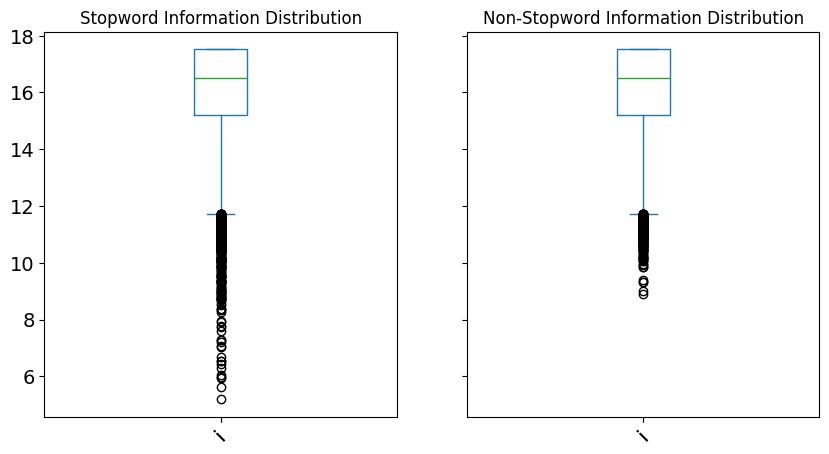

In [78]:
# Box plot of stopword and non-sw information
fig0, (ax1, ax2) = plt.subplots(1,2, sharex='all', sharey='all')

VOCAB['i'].plot.box(ax=ax1, figsize=(10,5), fontsize=14, rot=45, legend=False, title="Stopword Information Distribution")
VOCAB_nosw['i'].plot.box(ax=ax2, figsize=(10,5), fontsize=14, rot=45, legend=False, title="Non-Stopword Information Distribution")

plt.show()

Stopwords and non-stopwords generally both have high information and have very similar means, but stopwords have a longer, lower tail. 

In [79]:
VOCAB

n         p          i      p_yr       i_yr  stop
year term_str                                                      
2013 the       3045  0.016252   5.943196  0.063549   3.975993     1
     of        1810  0.009661   6.693649  0.037774   4.726446     1
     and       1433  0.007649   7.030600  0.029907   5.063397     1
     in        1206  0.006437   7.279408  0.025169   5.312206     1
     to         967  0.005161   7.598051  0.020181   5.630848     1
...             ...       ...        ...       ...        ...   ...
2023 consoles     1  0.000005  17.515423  0.000013  16.287604     0
     opt          1  0.000005  17.515423  0.000013  16.287604     0
     azure        1  0.000005  17.515423  0.000013  16.287604     0
     console      1  0.000005  17.515423  0.000013  16.287604     0
     xbox         1  0.000005  17.515423  0.000013  16.287604     0

[21582 rows x 6 columns]

### View Statistics of Stopwords

In [80]:
# Add n_chars, pos
VOCAB['n_chars'] = VOCAB.index.get_level_values("term_str").str.len()
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
# Explore the means
VOCAB.groupby('stop').agg({'n_chars':'mean', 'n_pos':'mean'})

,n_chars,n_pos
stop,,
0,7.76817,1.449633
1,3.62426,1.857988


Stopwords tend to be over half as long as non-stopwords. This makes sense given the long terminology (non-stopwords) used in science. They have slightly fewer (but not by much) numbers of parts of speech, perhaps because scientific literature uses such specific words that have very few possible parts of speech.

### Comparing Stopword Usage Across Years

In [81]:
YEAR = CORPUS.merge(LIB.reset_index()[['doc_id','year']], on='doc_id')\
    .merge(VOCAB.reset_index()[['term_str', 'stop']], on='term_str')\
    .groupby(['year','stop']).agg('sum', numeric_only=True).unstack()
YEAR.columns = YEAR.columns.droplevel(0)
(YEAR.T / YEAR.T.sum()).T.style.background_gradient(axis=None)

stop,0,1
year,,
2013,0.586537,0.413463
2018,0.576348,0.423652
2023,0.590651,0.409349


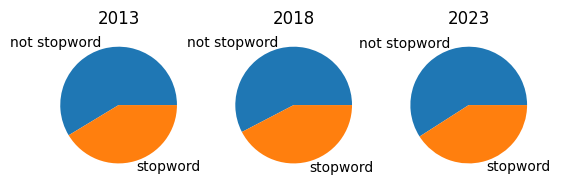

In [105]:
# Some help from Claude here

axes = (YEAR.T / YEAR.T.sum()).plot.pie(subplots=True, legend=False, labels=['not stopword', 'stopword'])

for ax, year in zip(axes, YEAR.index):
    ax.set_title(year)

sns.despine()
plt.show()

Values do not differ greatly by year.

### Explore Stems

In [83]:
VOCAB

n         p          i      p_yr       i_yr  stop  n_chars  \
year term_str                                                                  
2013 the       3045  0.016252   5.943196  0.063549   3.975993     1        3   
     of        1810  0.009661   6.693649  0.037774   4.726446     1        2   
     and       1433  0.007649   7.030600  0.029907   5.063397     1        3   
     in        1206  0.006437   7.279408  0.025169   5.312206     1        2   
     to         967  0.005161   7.598051  0.020181   5.630848     1        2   
...             ...       ...        ...       ...        ...   ...      ...   
2023 consoles     1  0.000005  17.515423  0.000013  16.287604     0        8   
     opt          1  0.000005  17.515423  0.000013  16.287604     0        3   
     azure        1  0.000005  17.515423  0.000013  16.287604     0        5   
     console      1  0.000005  17.515423  0.000013  16.287604     0        7   
     xbox         1  0.000005  17.515423  0.000013  16.287604     0        4   

               n_pos  
year term_str         
2013 the           1  
     of            1  
     and           2  
     in            2  
     to            1  
...              ...  
2023 consoles      1  
     opt           1  
     azure         1  
     console       1  
     xbox          1  

[21582 rows x 8 columns]

In [84]:
# Porter stemmer
VOCAB['stem_porter'] = VOCAB.apply(lambda x: PorterStemmer().stem(x.name[-1]), 1) # [-1] from Claude

# Snowball stemmer (English)
VOCAB['stem_snowball'] = VOCAB.apply(lambda x: SnowballStemmer("english").stem(x.name[-1]), 1)

# Lancaster stemmer
VOCAB['stem_lancaster'] = VOCAB.apply(lambda x: LancasterStemmer().stem(x.name[-1]), 1)

# View
VOCAB.sample(10)

n         p          i      p_yr       i_yr  stop  n_chars  \
year term_str                                                                  
2023 carya        1  0.000005  17.515423  0.000013  16.287604     0        5   
     cleared      2  0.000011  16.515423  0.000025  15.287604     0        7   
2013 bandwidth    1  0.000005  17.515423  0.000021  15.548220     0        9   
     pachyseris   7  0.000037  14.708068  0.000146  12.740865     0       10   
     deployed     7  0.000037  14.708068  0.000146  12.740865     0        8   
2023 dioxides     4  0.000021  15.515423  0.000050  14.287604     0        8   
2018 dual         3  0.000016  15.930460  0.000050  14.274330     0        4   
2023 0993         1  0.000005  17.515423  0.000013  16.287604     0        4   
     25          18  0.000096  13.345498  0.000225  12.117679     0        2   
2018 focus       18  0.000096  13.345498  0.000303  11.689367     0        5   

                 n_pos stem_porter stem_snowball stem_lancaster  
year term_str                                                    
2023 carya           1       carya         carya           cary  
     cleared         1       clear         clear          clear  
2013 bandwidth       2   bandwidth     bandwidth        bandwid  
     pachyseris      1   pachyseri     pachyseri         pachys  
     deployed        4      deploy        deploy         deploy  
2023 dioxides        1      dioxid        dioxid         dioxid  
2018 dual            1        dual          dual           dual  
2023 0993            1        0993          0993           0993  
     25              3          25            25             25  
2018 focus           3        focu         focus            foc

In [85]:
# View differences
VOCAB[VOCAB.stem_porter != VOCAB.stem_lancaster]

n         p          i      p_yr       i_yr  stop  \
year term_str                                                            
2013 were          369  0.001970   8.987946  0.007701   7.020743     1   
     are           302  0.001612   9.277018  0.006303   7.309815     1   
     was           290  0.001548   9.335514  0.006052   7.368311     1   
     species       202  0.001078   9.857211  0.004216   7.890008     0   
     coral         188  0.001003   9.960834  0.003924   7.993631     0   
...                ...       ...        ...       ...        ...   ...   
2023 solopreneurs    1  0.000005  17.515423  0.000013  16.287604     0   
     alibaba         1  0.000005  17.515423  0.000013  16.287604     0   
     leveraged       1  0.000005  17.515423  0.000013  16.287604     0   
     augmented       1  0.000005  17.515423  0.000013  16.287604     0   
     azure           1  0.000005  17.515423  0.000013  16.287604     0   

                   n_chars  n_pos  stem_porter stem_snowball stem_lancaster  
year term_str                                                                
2013 were                4      1         were          were            wer  
     are                 3      1          are           are             ar  
     was                 3      1           wa           was            was  
     species             7      5        speci         speci          specy  
     coral               5      3        coral         coral            cor  
...                    ...    ...          ...           ...            ...  
2023 solopreneurs       12      1  solopreneur   solopreneur         solopr  
     alibaba             7      1      alibaba       alibaba         alibab  
     leveraged           9      1      leverag       leverag            lev  
     augmented           9      1      augment       augment            aug  
     azure               5      1         azur          azur             az  

[8534 rows x 11 columns]

### Remove Stopwords

In [86]:
# Duplicate line just to keep logic clear
VOCAB_nosw = VOCAB[VOCAB['stop'] == 0]

### Visualization: Word Frequency Distributions by Year (No Stopwords)

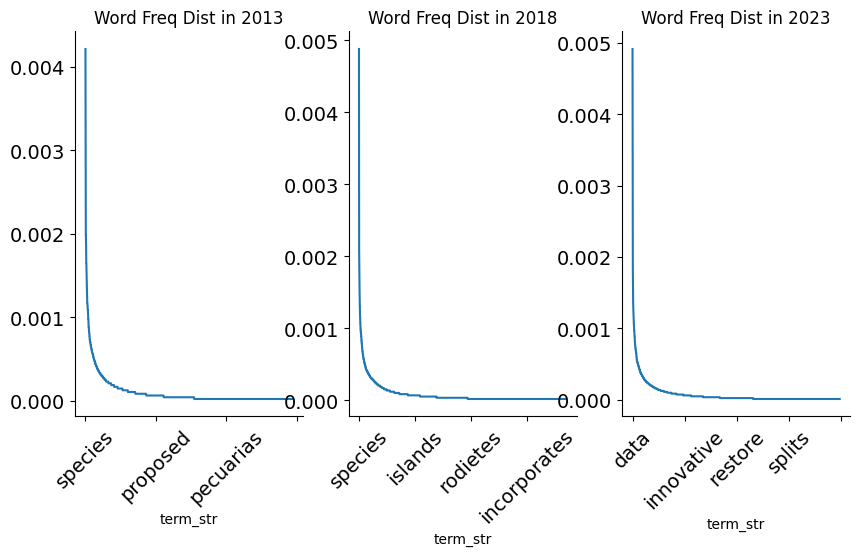

In [87]:
fig1, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].p_yr.plot(ax=axes[i], figsize=(10,5), fontsize=14, rot=45, legend=False, title=f"Word Freq Dist in {year}")
sns.despine()
plt.show()

### Visualization: Most Frequent Words by Year, Stopwords Removed

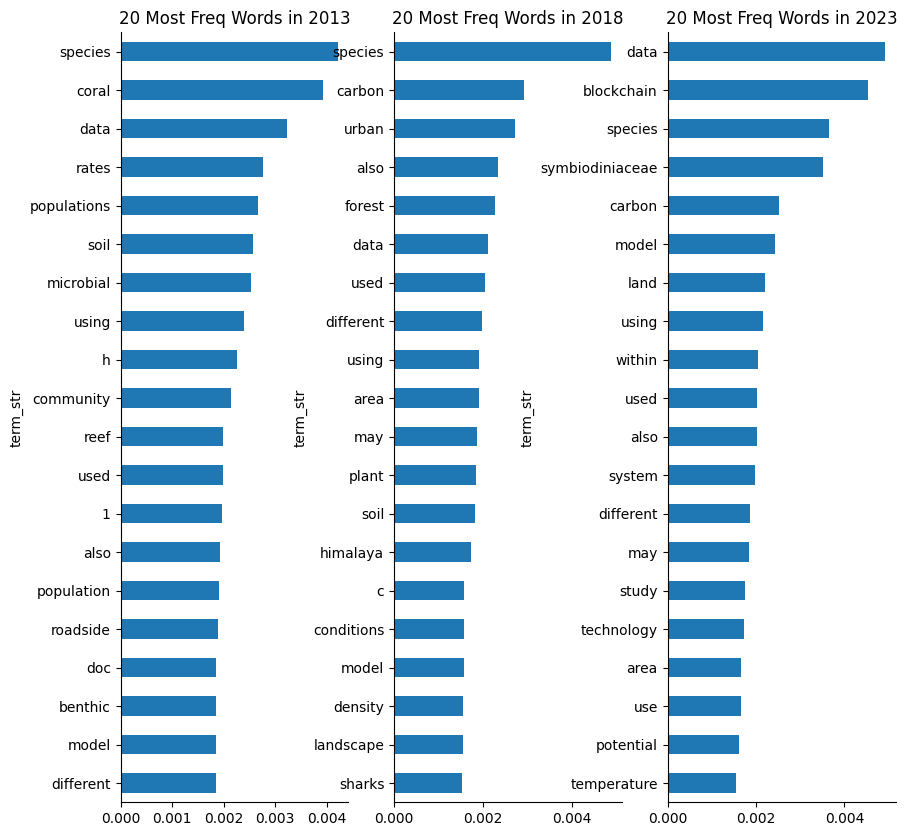

In [88]:
fig2, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].p_yr.head(20).sort_values().plot.barh(ax=axes[i], figsize=(10,10), title=f"20 Most Freq Words in {year}")
sns.despine()
plt.show()

Species is common in both 2013 and 2018 (words like coral, soil, and reef dominate 2013 and words like carbon, soil, and landscape predominate in 2018) suggesting a biological bent to the research, while data, blockchain, and technology become visible in 2023, suggesting the field may have moved more technological.

### Visualization: Per-Word Information Distribution by Year (No Stopwords)

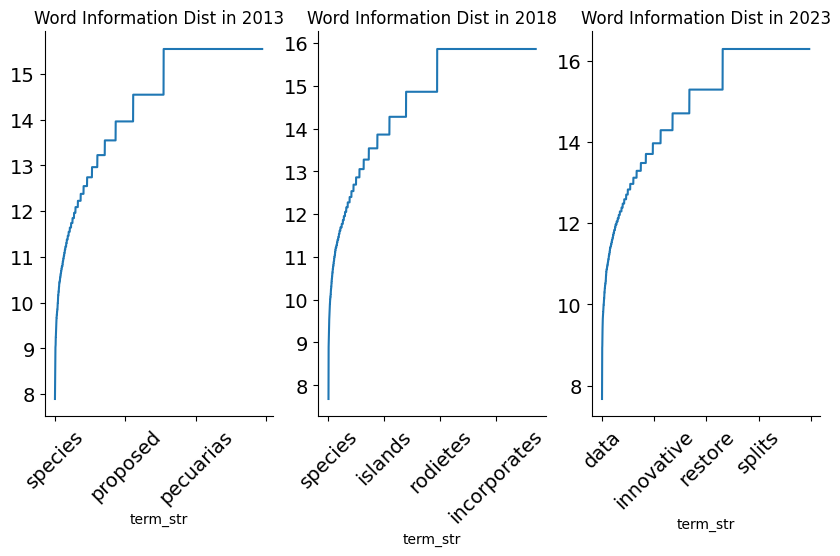

In [89]:
fig3, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].i_yr.plot(ax=axes[i], figsize=(10,5), fontsize=14, rot=45, legend=False, title=f"Word Information Dist in {year}")
sns.despine()
plt.show()

### Visualization: High-Information Words by Year, Stopwords Removed

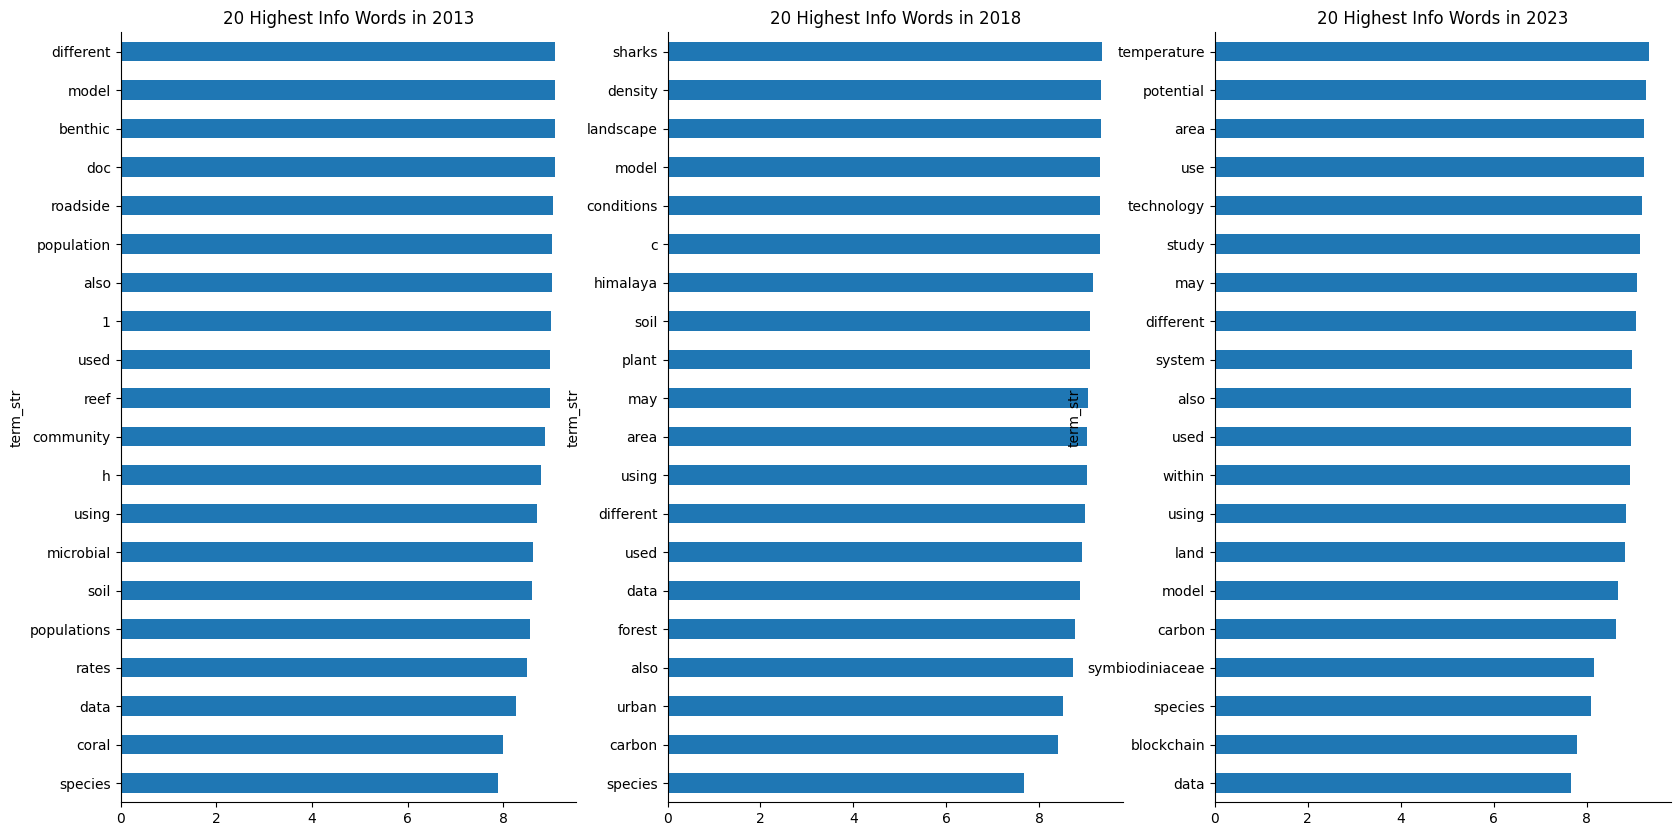

In [90]:
fig4_nosw, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].i_yr.head(20).sort_values().plot.barh(ax=axes[i], figsize=(20,10), title=f"20 Highest Info Words in {year}")
sns.despine()
plt.show()

Once again, biologically-based words such as benthic, reef, and soil carry high information in 2013, with similarly biological words like shark, landscape, and forest in 2018. Technologically-based words such as technology, blockchain, and data carry high information in 2023. The trend about which I've hypothesized continues and I look forward to exploring more. 

### File Saving

In [93]:
VOCAB_nosw.to_csv("csvs/VOCAB/VOCAB_nosw", index=False)